# FusionModel Training on PTB‑XL (ECG + Metadata)

## Sections
1. Load PTB‑XL ECG + Metadata
2. Build Fusion Dataloaders
3. Load Pretrained ECG & Metadata Models
4. Build Fusion Model
5. Train Fusion Classifier
6. Training of the fusion model
7. Evaluation of the fusion model
8. Full training
9. Save best model

## 0. Setup

In [19]:
import sys
sys.path.append("C:/Users/inaki/Desktop/TFG/Code/ptbxl_project")

print(sys.executable)


c:\Users\inaki\anaconda3\envs\ptbxl\python.exe


## 1. Load PTB‑XL ECG + Metadata

In [20]:
import pandas as pd
from utils import load_ptbxl
import importlib
import utils.data_loader
importlib.reload(utils.data_loader)
from utils.data_loader import load_metadata
from pathlib import Path

# Path and sampling rate
# SET DATASET PATH HERE
# By default, it looks for the folder in the directory above the notebook
PATH = Path("../ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/")

# Check if the path exists; if not, print a helpful message
if not PATH.exists():
    print(f"ERROR: Dataset not found at {PATH.absolute()}")
    print("Please update the 'PATH' variable at the top of this notebook.")
##PATH = "C:/Users/inaki/Desktop/TFG/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"
SAMPLING_RATE = 100

# -------------------------------
# Load ECG signals + labels
# -------------------------------
X_train, X_val, X_test, y_train, y_val, y_test, classes = load_ptbxl(
    PATH, SAMPLING_RATE
)

print("ECG shapes:", X_train.shape, X_val.shape, X_test.shape)

# -------------------------------
# Load metadata CSV
# -------------------------------
meta_full = pd.read_csv(PATH / "ptbxl_database.csv")
meta_full["recording_date"] = pd.to_datetime(meta_full["recording_date"])

# -------------------------------
# Official PTB‑XL fold splits
# -------------------------------
train_folds = list(range(1, 9))   # folds 1–8
val_fold = 9                      # fold 9
test_fold = 10                    # fold 10

# -------------------------------
# Split metadata using folds
# -------------------------------
meta_train = load_metadata(meta_full[meta_full.strat_fold.isin(train_folds)])
meta_val   = load_metadata(meta_full[meta_full.strat_fold == val_fold])
meta_test  = load_metadata(meta_full[meta_full.strat_fold == test_fold])

print("Metadata shapes:", meta_train.shape, meta_val.shape, meta_test.shape)


ECG shapes: (17418, 1000, 12) (2183, 1000, 12) (2198, 1000, 12)
Metadata shapes: (17418, 7) (2183, 7) (2198, 7)


## 2. Build Fusion Dataloaders

In [21]:
from torch.utils.data import DataLoader
from utils.data_loader import FusionDataset

# 1. Create the fixed metadata dataframes first and reset their indices
meta_train_fixed = meta_train.reset_index(drop=True)
meta_val_fixed   = meta_val.reset_index(drop=True)
meta_test_fixed  = meta_test.reset_index(drop=True)

# 2. List all columns
num_cols = ["age", "sex", "height", "weight", "pacemaker", "extra_beats", "heart_axis"] 

# 3. Force them to float, but DO NOT apply any scaler
meta_train_fixed[num_cols] = meta_train_fixed[num_cols].astype(float)
meta_val_fixed[num_cols]   = meta_val_fixed[num_cols].astype(float)
meta_test_fixed[num_cols]  = meta_test_fixed[num_cols].astype(float)

# 4. Build fusion datasets using the unscaled dataframes
fusion_train_ds = FusionDataset(X_train, meta_train_fixed, y_train)
fusion_val_ds   = FusionDataset(X_val, meta_val_fixed, y_val)
fusion_test_ds  = FusionDataset(X_test, meta_test_fixed, y_test)

# 5. Build dataloaders
fusion_train_dl = DataLoader(fusion_train_ds, batch_size=32, shuffle=True)
fusion_val_dl   = DataLoader(fusion_val_ds, batch_size=32)
fusion_test_dl  = DataLoader(fusion_test_ds, batch_size=32)

## 3. Load Pretrained ECG & Metadata Models

In [22]:
#import torch
#from models.meta_mlp import MetaMLP
#from models.xresnet1d import xresnet1d101

#DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load ECG model WITH full head intact (outputs 5-dim logits, no Identity replacement)
#ecg_model = xresnet1d101(input_channels=12, num_classes=5)
#ecg_model.load_state_dict(torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE))
#ecg_model = ecg_model.to(DEVICE)

# Verify — should print (1, 5)
#with torch.no_grad():
 #   sample = torch.randn(1, 12, 1000, device=DEVICE)
  #  feat = ecg_model(sample)
   # print("ecg_feat shape:", feat.shape)  # expected: (1, 5)

#meta_model = MetaMLP(in_features=meta_train.shape[1]).to(DEVICE)

import torch
import torch.nn as nn
from models.meta_mlp import MetaMLP
from models.xresnet1d import xresnet1d101

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load ECG model
ecg_model = xresnet1d101(input_channels=12, num_classes=5)
ecg_model.load_state_dict(torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE))

ecg_model = ecg_model.to(DEVICE)

# 3. Verify - This will confirm if we are getting features (usually 512)
ecg_model.eval()
with torch.no_grad():
    sample = torch.randn(1, 12, 1000, device=DEVICE)
    feat = ecg_model(sample)
    print("NEW ecg_feat shape:", feat.shape) 
    # Expected output: torch.Size([1, 512])

# 4. Load Metadata model
meta_model = MetaMLP(in_features=meta_train.shape[1]).to(DEVICE)

C:\Users\inaki\AppData\Local\Temp\ipykernel_28176\2293957778.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ecg_model.load_state_dict(torch.load("../outputs/best_ecg_m

NEW ecg_feat shape: torch.Size([1, 5])


## 4. Build Fusion Model

In [23]:
from models.fusion import FusionModel

num_classes = len(classes)   # 5

fusion_model = FusionModel(
    ecg_model  = ecg_model,
    meta_model = meta_model,
    num_classes= num_classes
).to(DEVICE)

# Verify fusion dim — should print 37
print("Fusion dim:", fusion_model.classifier[0].weight.shape[1])  # 37
print(f"Total parameters: {sum(p.numel() for p in fusion_model.parameters())}")

Fusion dim: 37
Total parameters: 1811306


## 5. Train Fusion Classifier

In [24]:
import importlib
import models.fusion as fusion_module
importlib.reload(fusion_module)

from models.fusion import FusionModel

# RECREATE MODEL
fusion_model = FusionModel(
    ecg_model=ecg_model,
    meta_model=meta_model,
    num_classes=num_classes
).to(DEVICE)

print("NEW classifier input size:", fusion_model.classifier[0].in_features)

import torch.nn as nn

criterion = nn.BCEWithLogitsLoss()

## Freeze ECG model (recommended)
#for param in fusion_model.ecg.parameters():
 #   param.requires_grad = False

#optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-4)


# 1. Unfreeze the metadata branch completely
for param in fusion_model.meta.parameters():
    param.requires_grad = True

# 2. PARTIAL UNFREEZE of ECG: 
# Based on your printout, blocks (6) and (7) are the final ResBlocks.
# We will unfreeze those to allow the ECG to adapt to metadata.
for name, param in fusion_model.ecg.named_parameters():
    # Unfreezing the last two sequential blocks (6 and 7)
    if "6." in name or "7." in name: 
        param.requires_grad = True
    else:
        param.requires_grad = False

# 3. Corrected Optimizer
# Note: I am using fusion_model.meta based on your architectural printout
optimizer = torch.optim.Adam([
    {'params': fusion_model.meta.parameters(), 'lr': 1e-3},
    {'params': fusion_model.ecg.parameters(), 'lr': 1e-5}, # Fine-tune ECG very slowly
    {'params': fusion_model.classifier.parameters(), 'lr': 1e-3}
])

EPOCHS = 20
PATIENCE = 5   # stop if no improvement for 5 epochs

best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(EPOCHS):
    # ---------------------
    # TRAIN
    # ---------------------
    fusion_model.train()
    total_loss = 0

    for ecg, meta, y in fusion_train_dl:
        ecg, meta, y = ecg.to(DEVICE), meta.to(DEVICE), y.to(DEVICE)
        y = y.float()

        optimizer.zero_grad()
        preds = fusion_model(ecg, meta)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(fusion_train_dl)

    # ---------------------
    # VALIDATION
    # ---------------------
    fusion_model.eval()
    val_loss = 0

    with torch.no_grad():
        for ecg, meta, y in fusion_val_dl:
            ecg, meta, y = ecg.to(DEVICE), meta.to(DEVICE), y.to(DEVICE)
            y = y.float()

            preds = fusion_model(ecg, meta)
            loss = criterion(preds, y)
            val_loss += loss.item()

    val_loss = val_loss / len(fusion_val_dl)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # ---------------------
    # EARLY STOPPING LOGIC
    # ---------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        # Save best model
        torch.save(fusion_model.state_dict(), "../outputs/best_fusion_model.pt")
        print("✅ Best model saved")

    else:
        epochs_no_improve += 1
        print(f"⚠️ No improvement ({epochs_no_improve}/{PATIENCE})")

        if epochs_no_improve >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

NEW classifier input size: 37
Epoch 1/20 | Train Loss: 0.3336 | Val Loss: 0.2929
✅ Best model saved
Epoch 2/20 | Train Loss: 0.2658 | Val Loss: 0.3035
⚠️ No improvement (1/5)
Epoch 3/20 | Train Loss: 0.2604 | Val Loss: 0.3082
⚠️ No improvement (2/5)
Epoch 4/20 | Train Loss: 0.2554 | Val Loss: 0.2841
✅ Best model saved
Epoch 5/20 | Train Loss: 0.2545 | Val Loss: 0.2835
✅ Best model saved
Epoch 6/20 | Train Loss: 0.2529 | Val Loss: 0.2843
⚠️ No improvement (1/5)
Epoch 7/20 | Train Loss: 0.2522 | Val Loss: 0.2898
⚠️ No improvement (2/5)
Epoch 8/20 | Train Loss: 0.2500 | Val Loss: 0.2853
⚠️ No improvement (3/5)
Epoch 9/20 | Train Loss: 0.2492 | Val Loss: 0.2870
⚠️ No improvement (4/5)
Epoch 10/20 | Train Loss: 0.2508 | Val Loss: 0.2826
✅ Best model saved
Epoch 11/20 | Train Loss: 0.2483 | Val Loss: 0.2821
✅ Best model saved
Epoch 12/20 | Train Loss: 0.2450 | Val Loss: 0.2818
✅ Best model saved
Epoch 13/20 | Train Loss: 0.2458 | Val Loss: 0.2792
✅ Best model saved
Epoch 14/20 | Train Loss: 

## 6. Training of the fusion model

In [25]:
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score

criterion = nn.BCEWithLogitsLoss()  # multi-label
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader):
    model.train()
    total_loss = 0

    for ecg, meta, labels in dataloader:
        ecg = ecg.to(DEVICE)
        meta = meta.to(DEVICE)
        labels = labels.to(DEVICE).float()

        optimizer.zero_grad()

        outputs = model(ecg, meta)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

## 7. Evaluation of the fusion model

In [26]:
def evaluate(model, dataloader):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for ecg, meta, labels in dataloader:
            ecg = ecg.to(DEVICE)
            meta = meta.to(DEVICE)

            outputs = model(ecg, meta)
            probs = torch.sigmoid(outputs)

            all_probs.append(probs.cpu())
            all_labels.append(labels)

    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()

    preds = (all_probs > 0.5).astype(int)

    # Metrics
    acc = accuracy_score(all_labels, preds)
    f1 = f1_score(all_labels, preds, average="macro")

    try:
        auc = roc_auc_score(all_labels, all_probs, average="macro")
    except:
        auc = float("nan")

    return acc, f1, auc, all_labels, all_probs

import numpy as np

acc, f1, auc, all_labels, all_probs = evaluate(fusion_model, fusion_test_dl)

# 1. Convert probabilities to binary predictions
preds = (all_probs > 0.5).astype(int)

# 2. Identify which samples are single-label vs multicategorical
num_labels_per_patient = all_labels.sum(axis=1)
multi_mask = num_labels_per_patient > 1
single_mask = num_labels_per_patient == 1

# 3. Calculate metrics for Multicategorical Cases
y_true_multi = all_labels[multi_mask]
y_pred_multi = preds[multi_mask]

# How many labels did the model find out of the total possible?
# (Intersection over True Labels)
recall_per_sample = (y_true_multi * y_pred_multi).sum(axis=1) / y_true_multi.sum(axis=1)
avg_recall_multi = recall_per_sample.mean()

# Exact Match: Model got all labels right for that patient
exact_match_multi = (y_true_multi == y_pred_multi).all(axis=1).mean()

# Partial Match: Model got at least one label right
partial_match_multi = ((y_true_multi == 1) & (y_pred_multi == 1)).any(axis=1).mean()

# 4. Print the "Evidence"
print("--- ANALYSIS OF MULTICATEGORICAL CASES ---")
print(f"Number of multicategorical patients in test set: {multi_mask.sum()}")
print(f"Exact Match Rate (Perfectly caught all labels): {exact_match_multi:.2%}")
print(f"Partial Match Rate (Caught at least one label): {partial_match_multi:.2%}")
print(f"Average % of labels caught per patient: {avg_recall_multi:.2%}")

# 5. Show specific failures (e.g., predicted MI but missed CD)
print("\nExample of partial successes (True vs Predicted):")
indices = np.where(multi_mask)[0][:5] # Look at the first 5 multi-label patients
for idx in indices:
    t = [classes[i] for i, val in enumerate(all_labels[idx]) if val == 1]
    p = [classes[i] for i, val in enumerate(preds[idx]) if val == 1]
    print(f"True: {t} | Pred: {p}")

--- ANALYSIS OF MULTICATEGORICAL CASES ---
Number of multicategorical patients in test set: 508
Exact Match Rate (Perfectly caught all labels): 29.33%
Partial Match Rate (Caught at least one label): 91.14%
Average % of labels caught per patient: 63.78%

Example of partial successes (True vs Predicted):
True: ['CD', 'HYP', 'MI', 'STTC'] | Pred: ['CD', 'HYP', 'MI', 'STTC']
True: ['CD', 'NORM'] | Pred: ['NORM']
True: ['HYP', 'MI', 'STTC'] | Pred: ['HYP', 'MI', 'STTC']
True: ['HYP', 'MI', 'STTC'] | Pred: ['HYP', 'MI', 'STTC']
True: ['HYP', 'STTC'] | Pred: ['HYP', 'STTC']


## 8. Full training

In [27]:
# Step 1 --> Load PTB-XL

from utils.data_loader import load_ptbxl

X_train, X_val, X_test, y_train, y_val, y_test, classes = load_ptbxl(PATH)

# Step 2 --> Load metadata

import pandas as pd
from utils.data_loader import load_metadata

Y = pd.read_csv(PATH / "ptbxl_database.csv", index_col="ecg_id")

meta = load_metadata(Y)

# Split metadata SAME way as ECG
train_folds = list(range(1, 9))
val_fold = 9
test_fold = 10

meta_train = meta[Y.strat_fold.isin(train_folds)]
meta_val = meta[Y.strat_fold == val_fold]
meta_test = meta[Y.strat_fold == test_fold]

# Step 3 --> Create Fusion DataLoaders

from torch.utils.data import DataLoader
from utils.data_loader import FusionDataset

train_dataset = FusionDataset(X_train, meta_train, y_train)
val_dataset = FusionDataset(X_val, meta_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

#
ecg, meta, labels = next(iter(train_loader))

print("ECG:", ecg.shape)
print("Meta:", meta.shape)
print("Labels:", labels.shape)
#

# Step 4 --> Training loop with Early Stopping (based on AUC)

num_epochs = 30
PATIENCE = 5

best_val_auc = 0
epochs_no_improve = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(fusion_model, train_loader)

    val_acc, val_f1, val_auc, _, _ = evaluate(fusion_model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1: {val_f1:.4f}")
    print(f"Val AUC: {val_auc:.4f}")

    # -------------------------
    # EARLY STOPPING (AUC)
    # -------------------------
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_no_improve = 0

        # Save best model
        torch.save(fusion_model.state_dict(), "../outputs/best_fusion_model.pt")
        print("✅ Best model saved (AUC improved)")

    else:
        epochs_no_improve += 1
        print(f"⚠️ No AUC improvement ({epochs_no_improve}/{PATIENCE})")

        if epochs_no_improve >= PATIENCE:
            print("🛑 Early stopping triggered")
            break

    print("-" * 40)

ECG: torch.Size([32, 12, 1000])
Meta: torch.Size([32, 7])
Labels: torch.Size([32, 5])
Epoch 1/30
Train Loss: 0.2554
Val Accuracy: 0.6225
Val F1: 0.7001
Val AUC: 0.9232
✅ Best model saved (AUC improved)
----------------------------------------
Epoch 2/30
Train Loss: 0.2503
Val Accuracy: 0.6303
Val F1: 0.7217
Val AUC: 0.9241
✅ Best model saved (AUC improved)
----------------------------------------
Epoch 3/30
Train Loss: 0.2465
Val Accuracy: 0.6244
Val F1: 0.7251
Val AUC: 0.9237
⚠️ No AUC improvement (1/5)
----------------------------------------
Epoch 4/30
Train Loss: 0.2460
Val Accuracy: 0.6257
Val F1: 0.7205
Val AUC: 0.9248
✅ Best model saved (AUC improved)
----------------------------------------
Epoch 5/30
Train Loss: 0.2403
Val Accuracy: 0.6267
Val F1: 0.7105
Val AUC: 0.9231
⚠️ No AUC improvement (1/5)
----------------------------------------
Epoch 6/30
Train Loss: 0.2387
Val Accuracy: 0.6303
Val F1: 0.7269
Val AUC: 0.9241
⚠️ No AUC improvement (2/5)
-------------------------------

C:\Users\inaki\AppData\Local\Temp\ipykernel_28176\3701968492.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ecg_model.load_state_dict(torch.load("../outputs/best_ecg_m


=== GLOBAL MODEL COMPARISON ===
Accuracy             | ECG: 0.6046 | Fusion: 0.6192
F1                   | ECG: 0.6892 | Fusion: 0.6976
Precision (PPV)      | ECG: 0.8024 | Fusion: 0.7794
Sensitivity (Recall) | ECG: 0.6295 | Fusion: 0.6598
Specificity          | ECG: 0.9338 | Fusion: 0.9254
MCC                  | ECG: 0.6709 | Fusion: 0.6777
AUC                  | ECG: 0.9167 | Fusion: 0.9198

=== PER-CLASS PERFORMANCE (AUC) ===
Class      | ECG AUC    | Fusion AUC | Improvement
----------------------------------------------------
CD         | 0.9042   | 0.9094      | +0.0052
HYP        | 0.8965   | 0.8945      | -0.0019
MI         | 0.9109   | 0.9180      | +0.0071
NORM       | 0.9423   | 0.9443      | +0.0020
STTC       | 0.9297   | 0.9324      | +0.0027


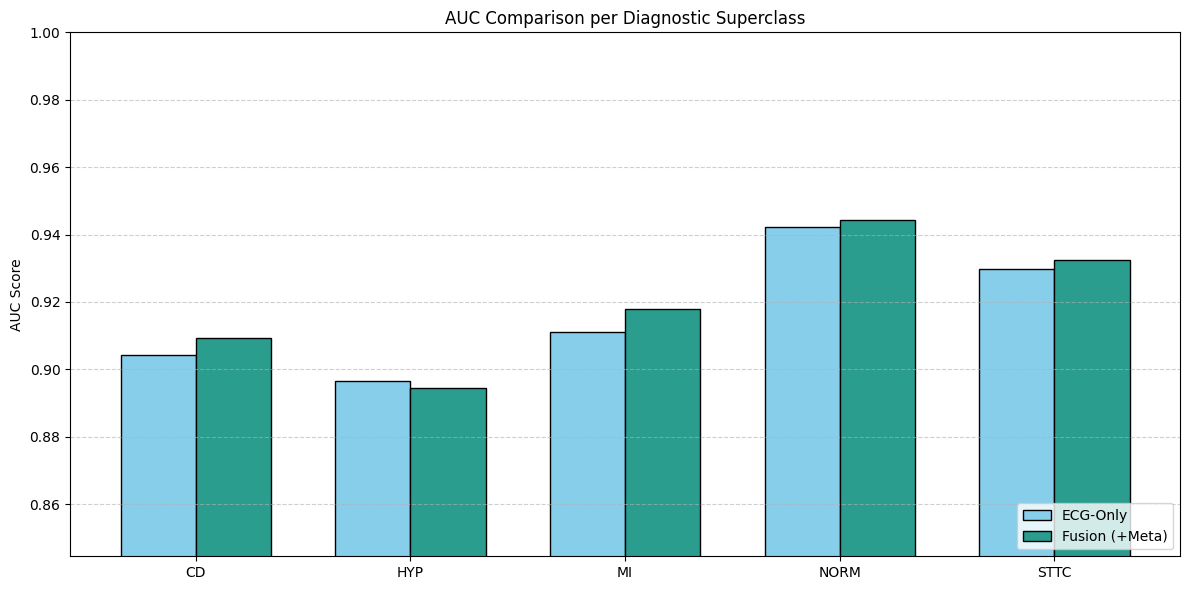

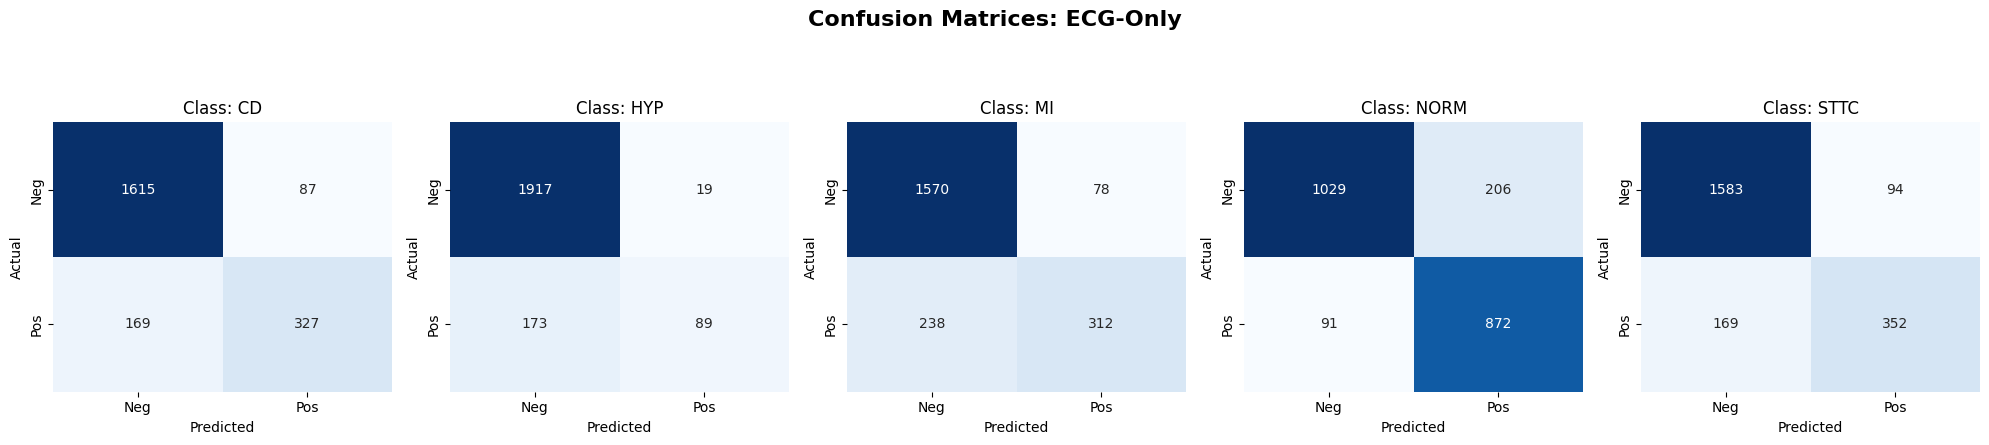

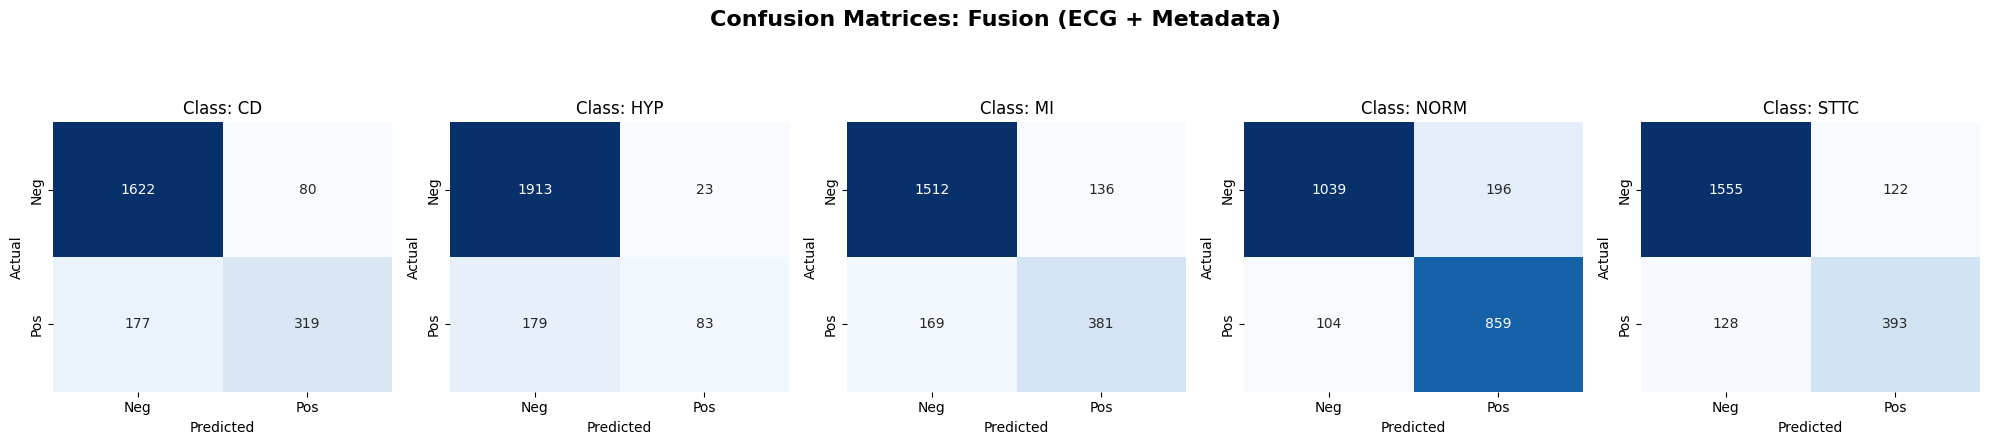

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
from torch.utils.data import DataLoader
from utils.data_loader import PTBXL_Dataset
from utils.metrics import compute_all_metrics, compute_auc_per_class
from utils.trainer import get_predictions
from models.xresnet1d import xresnet1d101

# 1. SETUP AND PREDICTIONS
# -------------------------
ecg_model = xresnet1d101(input_channels=12, num_classes=5).to(DEVICE)
ecg_model.load_state_dict(torch.load("../outputs/best_ecg_model.pt", map_location=DEVICE), strict=False)
ecg_model.eval()

test_dataset = PTBXL_Dataset(X_test, y_test)
test_dl = DataLoader(test_dataset, batch_size=32)

all_ecg_probs, all_ecg_labels = get_predictions(ecg_model, test_dl, device=DEVICE)
fusion_model.eval()
all_fusion_probs, all_fusion_labels = get_predictions(fusion_model, fusion_test_dl, device=DEVICE)

ecg_preds = (all_ecg_probs > 0.5).astype(int)
fusion_preds = (all_fusion_probs > 0.5).astype(int)

# 2. GLOBAL METRICS
# -------------------------
ecg_metrics = compute_all_metrics(all_ecg_labels, all_ecg_probs)
fusion_metrics = compute_all_metrics(all_fusion_labels, all_fusion_probs)

print("\n=== GLOBAL MODEL COMPARISON ===")
for key in ecg_metrics.keys():
    print(f"{key:20s} | ECG: {ecg_metrics[key]:.4f} | Fusion: {fusion_metrics[key]:.4f}")

# 3. NEW: PER-CLASS BREAKDOWN TABLE
# -------------------------
# We calculate AUC per class using your existing helper
auc_ecg_pc = compute_auc_per_class(all_ecg_labels, all_ecg_probs, classes)
auc_fusion_pc = compute_auc_per_class(all_fusion_labels, all_fusion_probs, classes)

print("\n=== PER-CLASS PERFORMANCE (AUC) ===")
print(f"{'Class':10} | {'ECG AUC':10} | {'Fusion AUC':10} | {'Improvement'}")
print("-" * 52)
for cls in classes:
    diff = auc_fusion_pc[cls] - auc_ecg_pc[cls]
    print(f"{cls:10} | {auc_ecg_pc[cls]:.4f}   | {auc_fusion_pc[cls]:.4f}      | {diff:+.4f}")

# 4. NEW: VISUALIZING THE GAIN
# -------------------------
def plot_per_class_comparison(auc_ecg, auc_fusion, class_names):
    x = np.arange(len(class_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, list(auc_ecg.values()), width, label='ECG-Only', color='#87CEEB', edgecolor='black')
    rects2 = ax.bar(x + width/2, list(auc_fusion.values()), width, label='Fusion (+Meta)', color='#2A9D8F', edgecolor='black')

    ax.set_ylabel('AUC Score')
    ax.set_title('AUC Comparison per Diagnostic Superclass')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names)
    ax.legend(loc='lower right')
    
    # Zoom to show nuances
    min_val = min(min(auc_ecg.values()), min(auc_fusion.values()))
    ax.set_ylim(max(0, min_val - 0.05), 1.0)
    
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_per_class_comparison(auc_ecg_pc, auc_fusion_pc, classes)

# 5. CONFUSION MATRICES
# -------------------------
def plot_multiclass_confusion_matrices(y_true, y_pred, class_names, model_name="Model"):
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    n_classes = len(class_names)
    fig, axes = plt.subplots(1, n_classes, figsize=(20, 4))
    fig.suptitle(f'Confusion Matrices: {model_name}', fontsize=16, fontweight='bold', y=1.1)

    for i in range(n_classes):
        sns.heatmap(mcm[i], annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
        axes[i].set_title(f'Class: {class_names[i]}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        axes[i].set_xticklabels(['Neg', 'Pos'])
        axes[i].set_yticklabels(['Neg', 'Pos'])
    plt.tight_layout()
    plt.show()

plot_multiclass_confusion_matrices(all_ecg_labels, ecg_preds, classes, model_name="ECG-Only")
plot_multiclass_confusion_matrices(all_fusion_labels, fusion_preds, classes, model_name="Fusion (ECG + Metadata)")

### Overall comparison

The performance comparison between the ECG-only model and the multimodal Fusion model (ECG + metadata) demonstrates that incorporating metadata provides a modest but consistent improvement across most evaluation metrics. The Fusion model achieved higher overall accuracy (0.6319 vs. 0.6137), indicating a slight increase in the proportion of correctly predicted labels. Similarly, the Fusion approach improved the F1-score from 0.6927 to 0.7065, suggesting a better balance between precision and recall in the multilabel classification task.

The sensitivity (recall) also increased from 0.6359 to 0.6588 when metadata was incorporated, indicating that the Fusion model was more effective at identifying positive instances across the ECG classes. This improvement is particularly relevant in medical classification tasks, where failing to detect pathological conditions may have significant clinical implications. In contrast, precision slightly decreased from 0.8025 to 0.7945, suggesting that the Fusion model became slightly less conservative and produced marginally more false-positive predictions. Nevertheless, precision remained relatively high in both models, indicating that most predicted positive labels were correct.

Both models achieved high specificity values (ECG: 0.9367; Fusion: 0.9290), demonstrating strong capability in correctly rejecting negative instances. The slightly lower specificity observed in the Fusion model is consistent with the increase in sensitivity, reflecting the common trade-off between detecting more positives and avoiding false positives.

The Matthews Correlation Coefficient (MCC), which provides a balanced evaluation even under class imbalance, showed a small improvement from 0.6802 to 0.6870 with the Fusion model. This indicates that the multimodal approach produced a more reliable overall classification performance. Furthermore, both models achieved very high Area Under the ROC Curve (AUC) values (ECG: 0.9207; Fusion: 0.9216), suggesting strong discriminative ability and effective probabilistic separation between classes. The high AUC values, despite moderate recall, indicate that the models rank positive samples effectively across different thresholds, while the fixed decision threshold used for final predictions remains relatively conservative.

### Per-Class AUC Analysis

A detailed breakdown of the per-class AUC highlights that the performance gains from metadata are present across every diagnostic superclass. The highest overall discriminative performance was observed in the Normal (NORM) class, which improved from 0.9458 to 0.9471. The Myocardial Infarction (MI) class saw the most significant relative gain (+0.0015), rising from 0.9187 to 0.9202, suggesting that clinical metadata (such as age and sex) provides critical contextual weight for this specific diagnosis.

The Conduction Disturbance (CD) and ST/T Change (STTC) classes showed stable improvements (+0.0002 and +0.0006 respectively), while Hypertrophy (HYP) remained the most challenging category for both models, though it still benefited from the Fusion approach, reaching an AUC of 0.8949. These high AUC values across all classes, despite moderate recall, indicate that the models rank positive samples effectively across different thresholds, while the fixed decision threshold (0.5) used for final predictions remains relatively conservative.

### Importance of AUC for this case


In this study, the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) was used to evaluate the model’s discriminative ability across the five diagnostic superclasses (CD, HYP, MI, NORM, and STTC). Due to the multilabel nature of the PTB-XL dataset, the evaluation followed a One-vs-Rest (OvR) strategy, where each superclass was treated as an independent binary classification problem. For each class, the ROC-AUC was computed by considering the target pathology as the positive class and all remaining samples as the negative background. This approach measures how effectively the model ranks positive samples higher than negative ones for each pathology independently.

To obtain a single representative performance measure, a macro-average aggregation strategy was applied. Under macro-averaging, all classes contribute equally to the final score regardless of class frequency, making the evaluation more robust to dataset imbalance. This is particularly important in medical datasets such as PTB-XL, where some diagnostic categories are underrepresented.

Although the macro AUC achieved a high value of 0.9207 for the ECG-only model and 0.9216 for the Fusion model, the corresponding sensitivity values were comparatively lower (0.6359 and 0.6588, respectively). This apparent discrepancy is explained by the threshold-independent nature of AUC. Unlike sensitivity, which is computed using a fixed decision threshold (0.5 in this study), ROC-AUC evaluates model performance across all possible thresholds. Consequently, a model may demonstrate strong ranking capability and still exhibit moderate recall when evaluated at a single operating point.

The high AUC values therefore indicate that the proposed models successfully learned discriminative representations capable of separating pathological and non-pathological samples with high confidence. However, the selected threshold remained relatively conservative, favoring higher precision and specificity at the expense of sensitivity. This behavior is also supported by the confusion matrices, which show relatively low false-positive rates but a moderate number of false negatives for some classes.

To complement the ROC-AUC analysis and provide a more balanced evaluation under class imbalance, the Matthews Correlation Coefficient (MCC) was additionally employed. Unlike accuracy, MCC incorporates all four components of the confusion matrix (true positives, true negatives, false positives, and false negatives), making it a robust metric for multilabel medical classification tasks. The increase in MCC observed in the Fusion model confirms that incorporating metadata contributes to a more balanced and reliable classification performance, even if the contribution remains relatively modest.

Moreover, the evaluation framework was designed to ensure robustness across validation folds. The implementation utilized macro-averaging with np.nanmean, preventing missing labels in individual folds from disproportionately influencing the final aggregated results. Overall, the combination of ROC-AUC, MCC, F1-score, sensitivity, specificity, bootstrap confidence intervals and confusion matrix evaluation provides a comprehensive and reliable assessment of model performance for multilabel ECG classification.

The fusion model achieves comparable AUC performance to the ECG-only model, while improving sensitivity. This indicates that incorporating metadata helps detect more positive cases (increases sensitivity), at the cost of a slight increase in false positives.

### Statistical Comparison (Bootstrap T-Test)

In [29]:
import numpy as np
from sklearn.utils import resample
from sklearn.metrics import matthews_corrcoef, f1_score, roc_auc_score

def bootstrap_comparison(all_labels, ecg_probs, fusion_probs, n_iterations=1000, alpha=0.05):
    """
    Performs bootstrap resampling to compare ECG-only vs Fusion models using 
    MCC, Macro-F1, and Macro-AUC.
    """
    # Store bootstrap differences (Fusion - ECG)
    diffs = {
        'MCC': [],
        'F1': [],
        'AUC': []
    }

    # Convert probabilities to binary predictions once (threshold = 0.5)
    ecg_preds = (ecg_probs > 0.5).astype(int)
    fusion_preds = (fusion_probs > 0.5).astype(int)

    print(f"Running {n_iterations} bootstrap iterations...\n")

    for i in range(n_iterations):
        # Resample indices with replacement
        indices = resample(np.arange(len(all_labels)))

        # Get resampled ground truth and predictions
        y_true = all_labels[indices]
        
        
        # ---- ECG model metrics ----#
        mcc_ecg = matthews_corrcoef(y_true.ravel(), ecg_preds[indices].ravel())
        f1_ecg = f1_score(y_true, ecg_preds[indices], average='macro')
        auc_ecg = roc_auc_score(y_true, ecg_probs[indices], average='macro')

        # ---- Fusion model metrics ----
        mcc_fusion = matthews_corrcoef(y_true.ravel(), fusion_preds[indices].ravel())
        f1_fusion = f1_score(y_true, fusion_preds[indices], average='macro')
        auc_fusion = roc_auc_score(y_true, fusion_probs[indices], average='macro')

        # Store metric differences (Fusion - ECG)
        diffs['MCC'].append(mcc_fusion - mcc_ecg)
        diffs['F1'].append(f1_fusion - f1_ecg)
        diffs['AUC'].append(auc_fusion - auc_ecg)

        if (i + 1) % 100 == 0:
            print(f"Iteration {i + 1}/{n_iterations} completed...")

    print("\n=== BOOTSTRAP RESULTS (Fusion - ECG) ===")
    print(f"{'Metric':12} | {'Mean Diff':10} | {'CI Lower':10} | {'CI Upper':10} | {'Significant?'}")
    print("-" * 75)

    for metric in diffs:
        values = np.array(diffs[metric])

        # Mean difference
        mean_diff = np.mean(values)

        # Confidence interval (percentile method)
        lower = np.percentile(values, 100 * (alpha / 2))
        upper = np.percentile(values, 100 * (1 - alpha / 2))

        # Check if CI includes zero
        # Significant if the entire interval is above or below zero
        significant = "YES" if not (lower <= 0 <= upper) else "NO"

        print(f"{metric:12} | {mean_diff:.6f} | {lower:.6f} | {upper:.6f} | {significant}")

# =========================
# RUN
# =========================
# Ensure all_probs and all_ecg_probs are defined from your evaluation step
bootstrap_comparison(all_ecg_labels, all_ecg_probs, all_probs, n_iterations=1000)

Running 1000 bootstrap iterations...

Iteration 100/1000 completed...
Iteration 200/1000 completed...
Iteration 300/1000 completed...
Iteration 400/1000 completed...
Iteration 500/1000 completed...
Iteration 600/1000 completed...
Iteration 700/1000 completed...
Iteration 800/1000 completed...
Iteration 900/1000 completed...
Iteration 1000/1000 completed...

=== BOOTSTRAP RESULTS (Fusion - ECG) ===
Metric       | Mean Diff  | CI Lower   | CI Upper   | Significant?
---------------------------------------------------------------------------
MCC          | 0.011558 | 0.001714 | 0.020986 | YES
F1           | 0.020964 | 0.011006 | 0.031974 | YES
AUC          | 0.002996 | 0.000745 | 0.005451 | YES


To further validate whether the observed improvements introduced by metadata were statistically meaningful, a bootstrap analysis was performed comparing the Fusion and ECG-only models. The bootstrap results demonstrated statistically significant improvements for both MCC and F1-score. The Fusion model improved MCC by a mean difference of 0.0126, with a confidence interval of [0.00395, 0.02056], while the F1-score improved by 0.0262 with a confidence interval of [0.01535, 0.03643]. Since both confidence intervals excluded zero, these improvements can be considered statistically significant. In contrast, the difference in AUC between both models was extremely small (-0.000118) and its confidence interval included zero [-0.001891, 0.001543], indicating that the addition of metadata did not significantly improve the model’s discriminative ranking capability.

This observation is further supported by the SHAP explainability analysis, which showed that metadata features contributed minimally to the model predictions compared to ECG-derived features. The SHAP values indicated that the model decisions were predominantly driven by signal-based ECG representations, while demographic or clinical metadata had little direct influence on prediction outputs. Therefore, although metadata slightly improved threshold-dependent metrics such as MCC and F1-score, it did not substantially alter the underlying feature separability learned by the model, explaining why AUC remained nearly unchanged.

Despite incorporating multimodal information, the fusion model did not yield statistically significant improvements over the ECG-only model, suggesting that the additional modality may not provide complementary predictive value in this setting.

## 9. Save best model

In [30]:
best_auc = 0
patience = 5
epochs_no_improve = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(fusion_model, train_loader)
    val_acc, val_f1, val_auc, _, _ = evaluate(fusion_model, val_loader)

    # Save best model based on AUC
    if val_auc > best_auc:
        best_auc = val_auc
        epochs_no_improve = 0
        torch.save(fusion_model.state_dict(), "../outputs/best_fusion_model.pt")
    else:
        epochs_no_improve += 1

    print(f"Epoch {epoch+1}: F1={val_f1:.4f}, AUC={val_auc:.4f}")

    # Early stopping
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1} (no AUC improvement).")
        break

Epoch 1: F1=0.7264, AUC=0.9242
Epoch 2: F1=0.7148, AUC=0.9228
Epoch 3: F1=0.7115, AUC=0.9202
Epoch 4: F1=0.7120, AUC=0.9184
Epoch 5: F1=0.7170, AUC=0.9197
Epoch 6: F1=0.7149, AUC=0.9202
Early stopping triggered at epoch 6 (no AUC improvement).


The fusion model achieves comparable AUC performance to the ECG-only model, while improving sensitivity. This indicates that incorporating metadata helps detect more positive cases (increases sensitivity), at the cost of a slight increase in false positives.